# Importing Essentials

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline


# 1.Importing Dataset

In [78]:
df=pd.read_csv('netflix_data.csv')

In [79]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [80]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [81]:
df.isna().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [82]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [83]:
df.shape

(8807, 12)

In [84]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# 2.Data cleaning 

### Removing Unnessary column

In [85]:
df = df.drop(columns=['description', 'cast'])
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,NaN,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


### Checking missing data

In [86]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
dtype: int64

### Filling missing data

In [87]:
df['director'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df.dropna(subset=['date_added'], inplace=True)
df.dropna(subset=['duration'], inplace=True)
df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_23364\3887667559.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_23364\3887667559.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,Unknown,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,Unknown,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


### Dropping duplicate if exist

In [88]:
df.drop_duplicates(inplace=True)
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,Unknown,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,Unknown,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


# 3. Data preprocessing

In [89]:
# convert date_added to date and type from object type
df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(),  # removes leading spaces
    errors='coerce'                # invalid dates → NaT
)
df['month_added'] = df['date_added'].dt.month.astype('Int64')


In [90]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,9
1,s2,TV Show,Blood & Water,Unknown,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",9
2,s3,TV Show,Ganglands,Julien Leclercq,Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",9
4,s5,TV Show,Kota Factory,Unknown,India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",9


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8794 non-null   object        
 1   type          8794 non-null   object        
 2   title         8794 non-null   object        
 3   director      8794 non-null   object        
 4   country       8794 non-null   object        
 5   date_added    8794 non-null   datetime64[ns]
 6   release_year  8794 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8794 non-null   object        
 9   listed_in     8794 non-null   object        
 10  month_added   8794 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), int64(1), object(8)
memory usage: 833.0+ KB


# Exporting Cleaned Dataset

In [92]:
df.to_csv("cleaned_netflix_data.csv", index=False)


# 4. Performing  EDA

##  * Distribution of Content Type (Movies vs TV Shows)

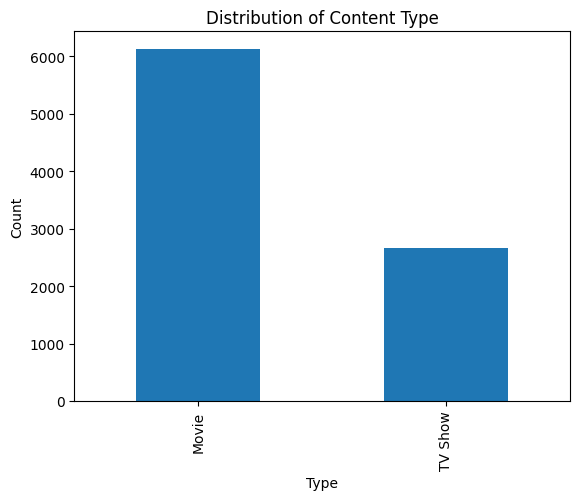

In [93]:
df['type'].value_counts().plot(kind='bar')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.savefig('movies_vs_tvshows.png')

## *Content Added Over Time (Year-wise)

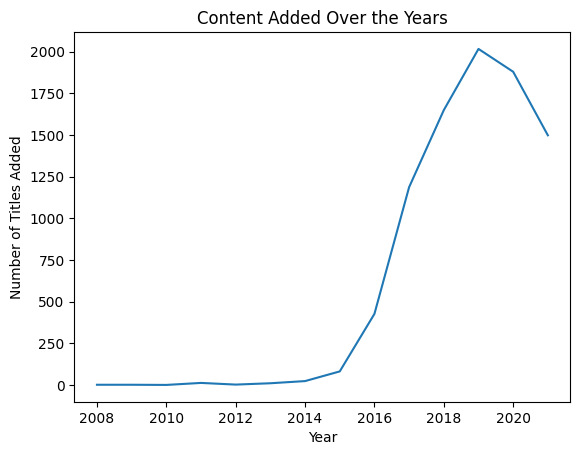

In [94]:
df['date_added'].dt.year.value_counts().sort_index().plot(kind='line')
plt.title('Content Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.savefig('year-wise_content_added.png')

## *Comparing movies and shows to increasee over time

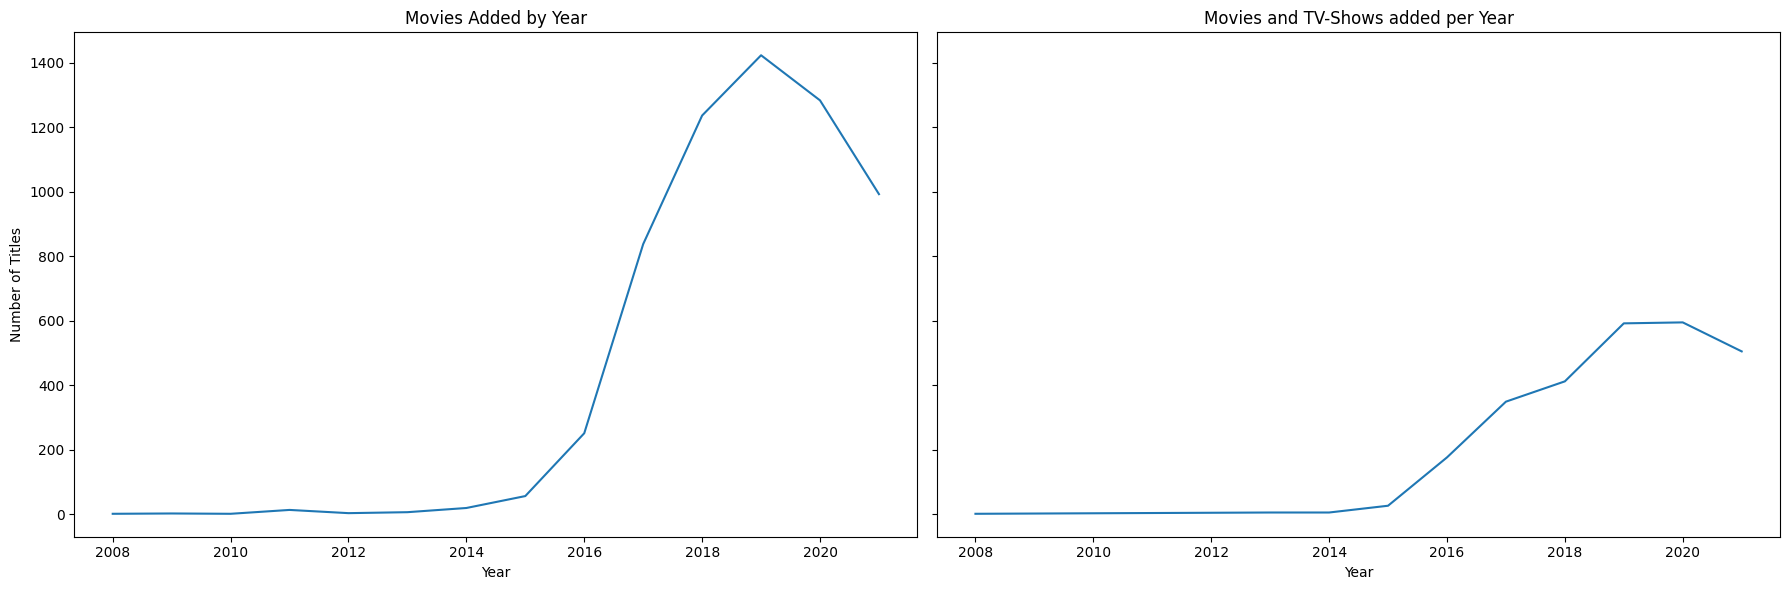

In [106]:
# Movies over time
movies = df[df['type'] == 'Movie']
movies_year = movies['date_added'].dt.year.value_counts().sort_index()

# TV Shows over time
shows = df[df['type'] == 'TV Show']
shows_year = shows['date_added'].dt.year.value_counts().sort_index()


fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)
# Movies plot
movies_year.plot(kind='line', ax=axes[0])
axes[0].set_title('Movies Added by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Titles')

# TV Shows plot
shows_year.plot(kind='line', ax=axes[1])
axes[1].set_title('TV Shows Added by Year')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.tight_layout()
plt.savefig('year-wise_Movie_and_TV-Show_added.png')

## *Content added monthly

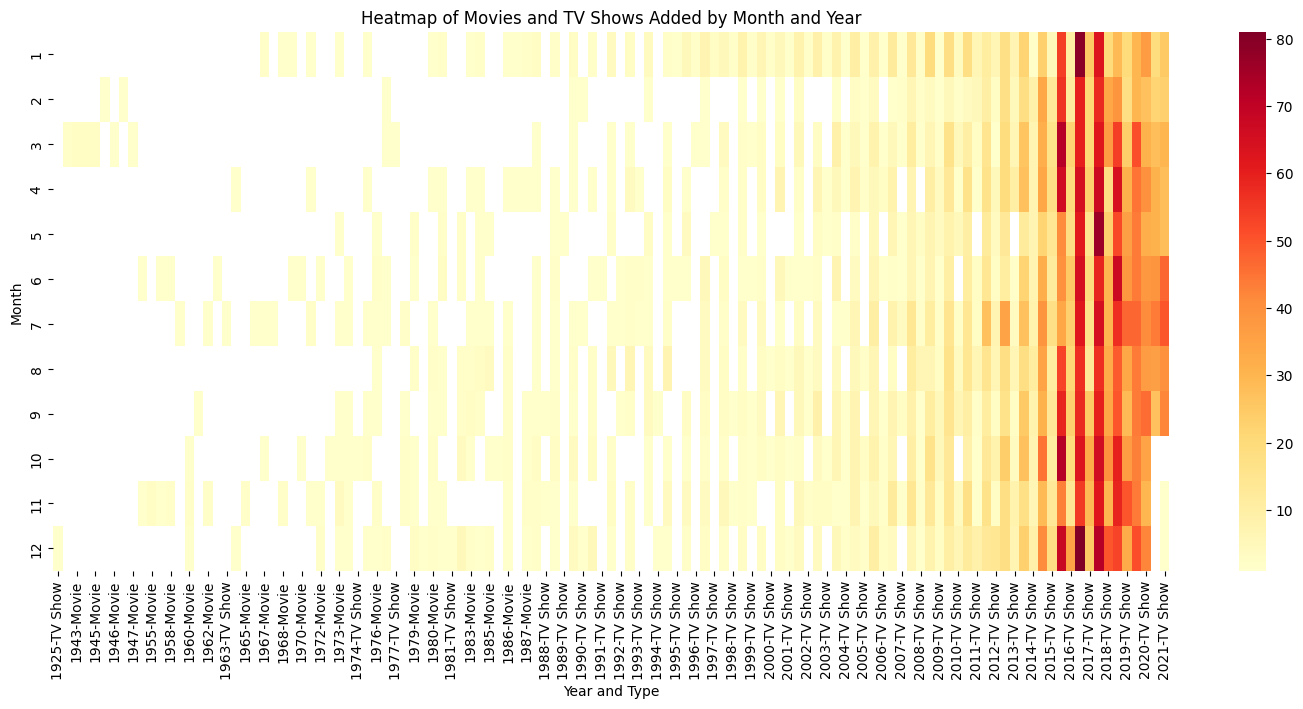

In [96]:
pivot = df.pivot_table(
    index='month_added',
    columns=['release_year', 'type'],
    values='show_id',
    aggfunc='count'
)
plt.figure(figsize=(18,7))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('Heatmap of Movies and TV Shows Added by Month and Year')
plt.xlabel('Year and Type')
plt.ylabel('Month')

plt.savefig('Shows_added_per_month_in_each_year.png')

## *Comparision of movies and shows addded per month

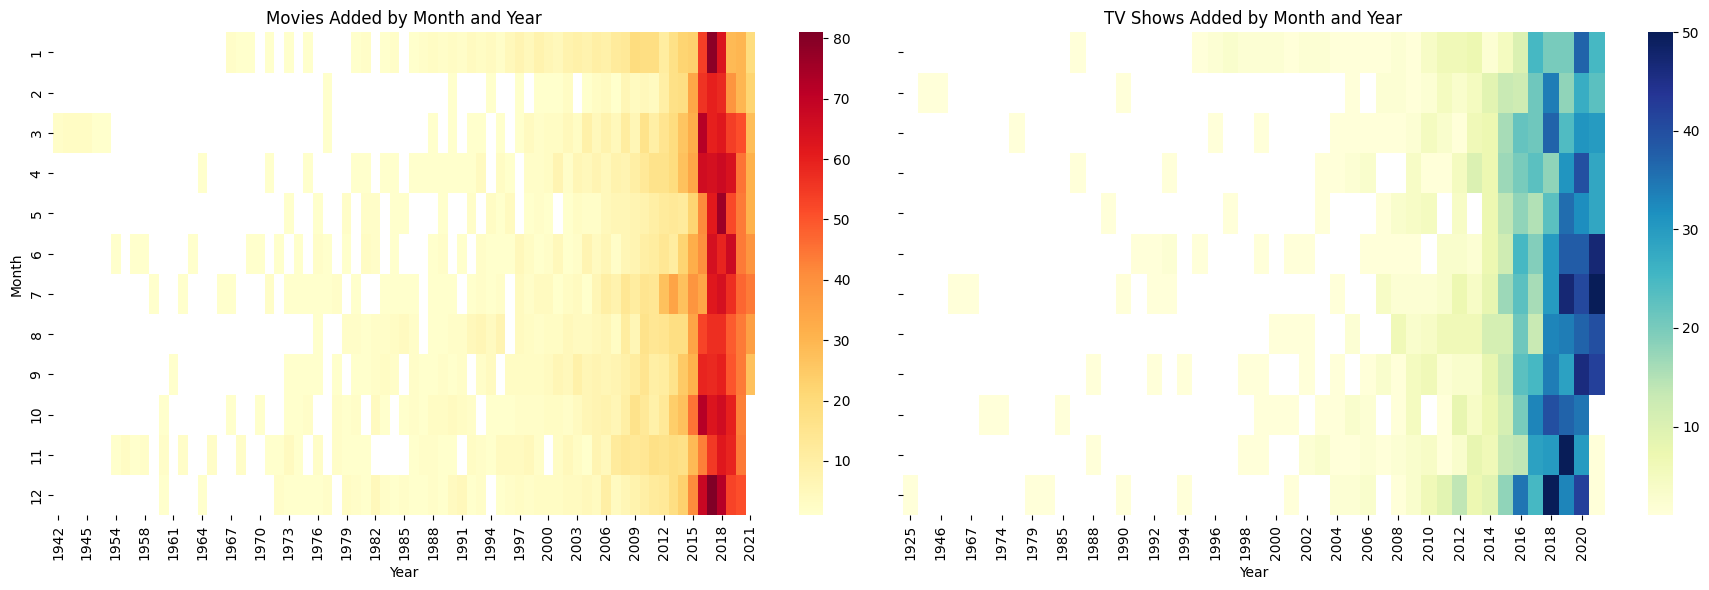

In [97]:
movies = df[df['type'] == 'Movie']
shows = df[df['type'] == 'TV Show']

movies_pivot = movies.pivot_table(
    index='month_added',
    columns='release_year',
    values='show_id',
    aggfunc='count'
)

shows_pivot = shows.pivot_table(
    index='month_added',
    columns='release_year',
    values='show_id',
    aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

sns.heatmap(movies_pivot, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Movies Added by Month and Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Month')

sns.heatmap(shows_pivot, cmap='YlGnBu', ax=axes[1])
axes[1].set_title('TV Shows Added by Month and Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('Movies_and_TV-Shows_added_per_month_in_each_year.png')

## *Release Year Distribution

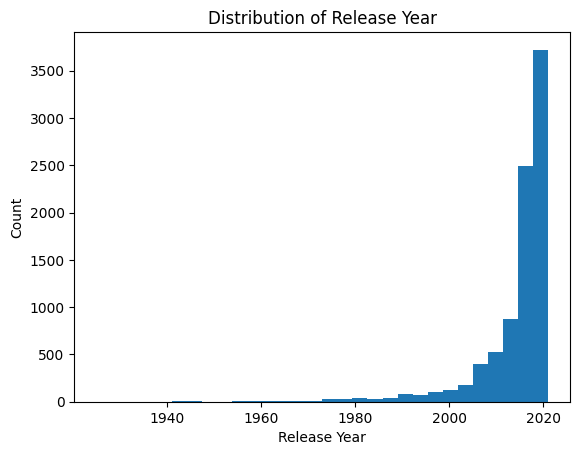

In [98]:
plt.hist(df['release_year'], bins=30)
plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.savefig('Showsreleased_per_year.png')

## *Rating Distribution

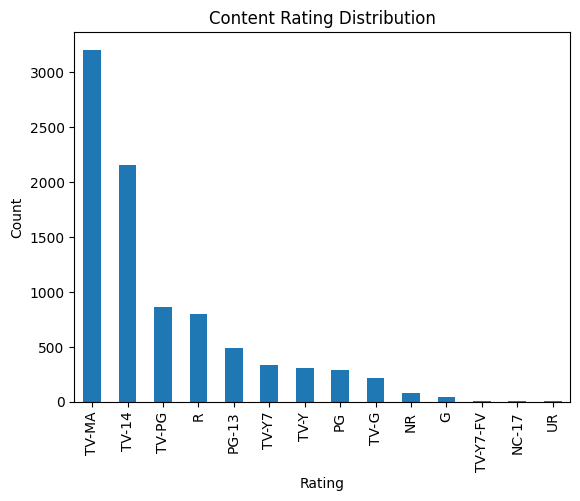

<Figure size 640x480 with 0 Axes>

In [99]:
df['rating'].value_counts().plot(kind='bar')
plt.title('Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()
plt.savefig('Top-10_rating-distribition.png')

## *Top 10 Content Producing Countries

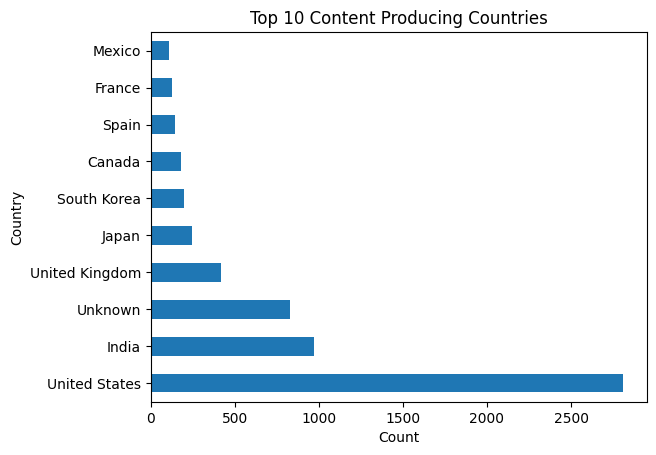

<Figure size 640x480 with 0 Axes>

In [100]:
df['country'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()
plt.savefig('Top-10_countries_with_most_Shows.png')

## *Top 10 Genre Distribution

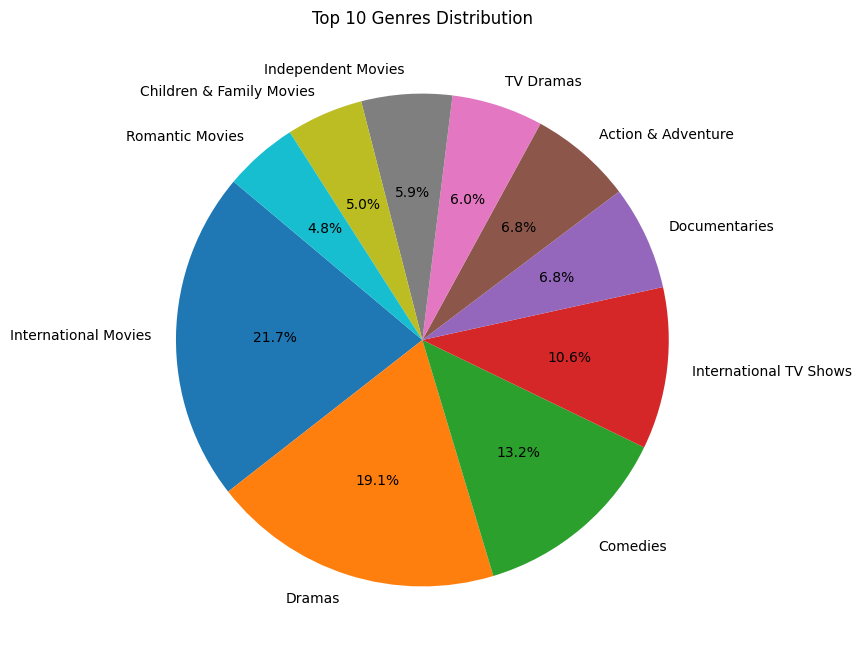

<Figure size 640x480 with 0 Axes>

In [101]:
genre_counts = (
    df['listed_in'].str.split(', ').explode().value_counts().head(10)
)

# Pie plot
plt.figure(figsize=(8,8))
genre_counts.plot( kind='pie',autopct='%1.1f%%',startangle=140
)

plt.title('Top 10 Genres Distribution')
plt.ylabel('')   # remove default ylabel
plt.show()
plt.savefig('Top-10_geners_available_distribution.png')

## *Duration Distribution (Movies)

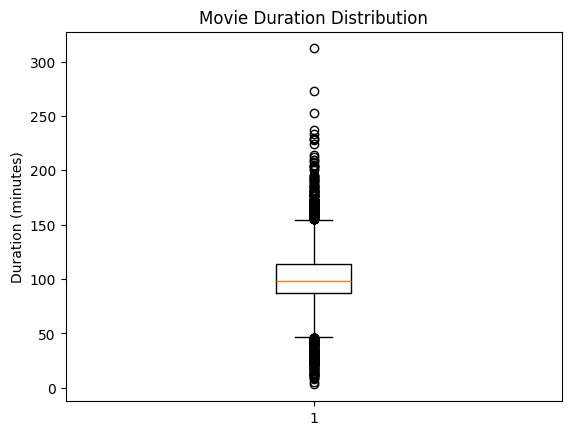

In [102]:
movie_duration = df[df['type'] == 'Movie']['duration'].str.extract(r'(\d+)').astype(int)

plt.boxplot(movie_duration)
plt.title('Movie Duration Distribution')
plt.ylabel('Duration (minutes)')

plt.savefig('Movies_average_duration.png')

## *TV Shows Season Count Distribution

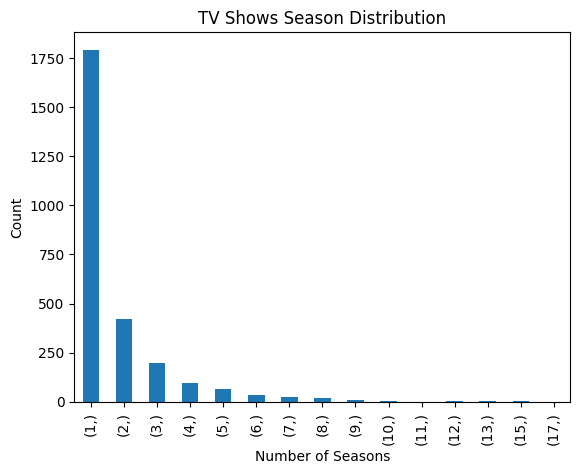

In [103]:
tv_seasons = df[df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(int)

tv_seasons.value_counts().sort_index().plot(kind='bar')
plt.title('TV Shows Season Distribution')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.savefig('TV-Shows_with-seasons_count.png')

## *Content Type vs Rating

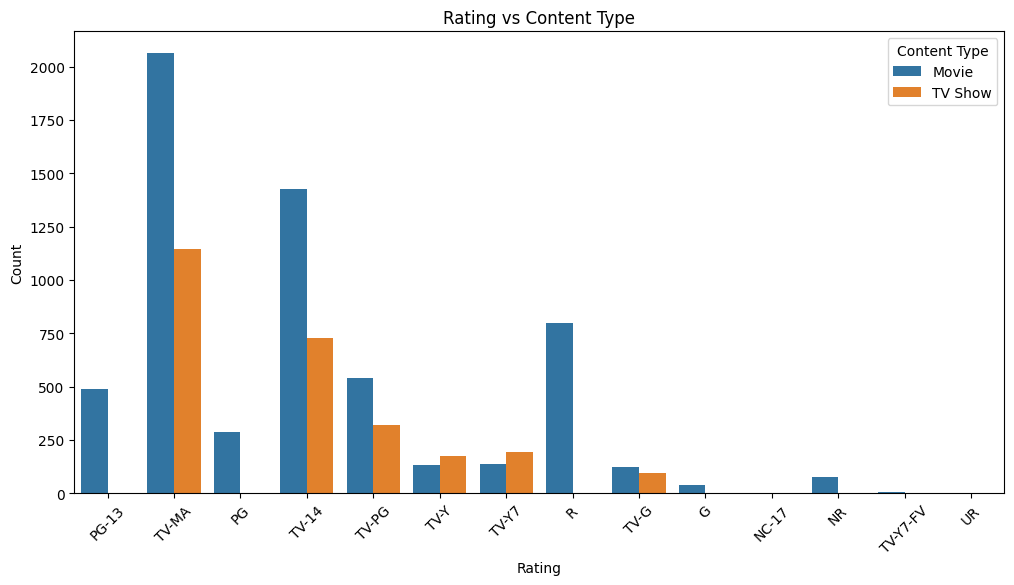

In [104]:
plt.figure(figsize=(12,6))

# Countplot with hue
sns.countplot(data=df, x='rating', hue='type')

plt.title('Rating vs Content Type')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(title='Content Type')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.savefig('Rating_distributed-basis_of_content.png')

## *Top 10 directors with most shows

C:\Users\Asus\AppData\Local\Temp\ipykernel_23364\806792577.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')


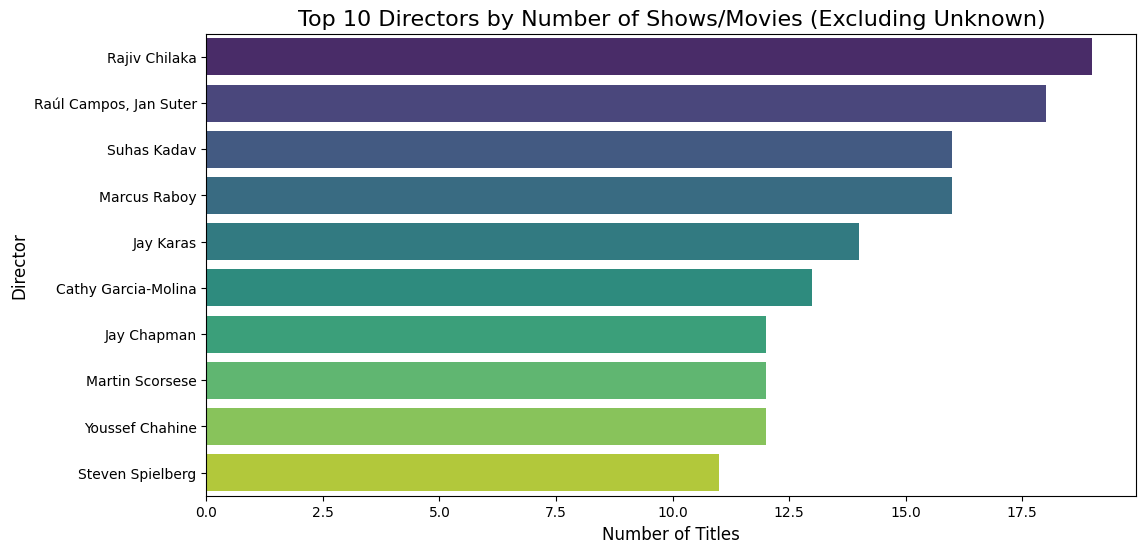

In [105]:
# Filter out 'Unknown'
directors_filtered = df[df['director'] != 'Unknown']


top_directors = directors_filtered['director'].value_counts().head(10)

# Count plot
plt.figure(figsize=(12,6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')
plt.title('Top 10 Directors by Number of Shows/Movies (Excluding Unknown)', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.savefig('mTop-10_Director_with_most_shows.png')